# Online Drift Detection on Real Validation Streams

**Chapter 26: MLOps and Governance**
**Docker image**: `ml4t`
**Book Reference**: Chapter 26, Section 26.3
**Prerequisites**: Drift basics from [`01_drift_monitoring`](01_drift_monitoring.ipynb) and Chapter 25 deployment verification.

**Learning Objectives**:
- Run two sequential drift detectors over a live error stream: a two-window mean-shift
  test on prediction error, and a bad-day frequency monitor in the style of the Drift
  Detection Method.
- Set each detector's sensitivity from a calibration period, so what counts as an alert
  is fixed before the period being monitored begins.
- Place each alert against an independent measure of how turbulent the market was, so a
  cluster of alerts can be read as a change in conditions rather than as model decay.
- Measure how far ahead of or behind a turbulence episode each detector fired, keeping
  the sign, since early and late warnings are different failures.

A *sequential* detector reads one observation at a time and decides after each whether
what it has seen so far looks like the stream it was calibrated on. That is the shape
monitoring takes in production, where the question arrives daily and there is no second
sample to compare against.

The stream here is real. `us_equities_panel` holds validation predictions for its linear
model grid, so the notebook watches two of those configurations through one calendar year
and asks how often a detector would have told a desk that the error stream was changing.
The holdout window is never read.

In [1]:
"""Online Drift Detection on Real Validation Streams: sequential detectors over a year of prediction error."""

'Online Drift Detection on Real Validation Streams: sequential detectors over a year of prediction error.'

## Settings

**What is watched.** `VALIDATION_START` and `VALIDATION_END` bound the year the detectors
run over, and `CALIBRATION_DAYS` splits it: the first stretch calibrates each detector and
raises no alerts, the rest is monitored. Calibrating on the same data being monitored would
let a detector tune itself to the shift it is supposed to find. Sixty-three sessions is a
quarter, enough for a bad-day rate to have a stable mean.

`OLS_CONFIG` and `RIDGE_CONFIG` name two configurations from the case study's linear grid by
the names the registry stores, not by prediction hash. A hash is content-addressed and moves
whenever the case study is refitted; a configuration name does not. The pair is the
unpenalized fit and a heavily penalized one, chosen so the two error streams are actually
different - adjacent penalties in this grid produce predictions that agree to five decimal
places, and comparing detector behaviour across two identical streams would look like a
result and be an artifact. The check below asserts they differ.

**Who is in the universe.** `TOP_N_LIQUID` keeps the most heavily traded names, ranked on the
year before the monitoring window so the ranking uses no information from inside it.
`MIN_ASSETS_PER_DATE` is the fewest names a session may carry before its cross-sectional
statistics stop meaning anything: with two or three names a daily rank correlation is plus or
minus one by construction, so what the detector reports is then an artifact of how many
names happened to survive the joins.

**How sensitive each detector is.** `ADWIN_WINDOW` sets how many sessions each of the
mean-shift detector's two windows holds, `ADWIN_SENSITIVITY` how many pooled standard errors
the two window means must differ by, and `ADWIN_COOLDOWN` how long it stays quiet after an
alert, so one sustained shift produces one alert rather than a run of them.

`DDM_MIN_SAMPLES` is how many sessions the bad-day monitor observes before it will alert.
`DDM_WARNING_SIGMA` and `DDM_DRIFT_SIGMA` are how many standard errors above its best
observed bad-day rate the current rate must sit to warn and to declare drift; two standard
errors is the conventional pair and, as with any test repeated daily, it fires on chance
alone often enough that its alerts are a queue to review rather than a finding.

`BAD_DAY_MARGIN` and `BAD_DAY_FLOOR` decide which sessions count as bad. A session is bad
when more than half its directional calls are wrong, or when it is worse than the
calibration period's own average by the margin, whichever is stricter. The floor exists
because a model that was already wrong more often than not during calibration would
otherwise set a bar it meets by standing still.

**The turbulence proxy.** `STRESS_VOL_WINDOW` is the width of the rolling volatility measure
and `STRESS_QUANTILE` the point in the calibration year's own distribution above which the
market counts as turbulent. Calibrating the threshold on the prior year and holding it fixed
is what makes the episodes in the monitored year events rather than a re-description of it.

In [2]:
CASE_STUDY_ID = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
VALIDATION_START = "2015-01-01"
VALIDATION_END = "2015-12-31"
CALIBRATION_DAYS = 63
OLS_CONFIG = "ols"
RIDGE_CONFIG = "ridge_a1000000.0"
TOP_N_LIQUID = 200
MIN_ASSETS_PER_DATE = 10
ADWIN_WINDOW = 21
ADWIN_SENSITIVITY = 1.4
ADWIN_COOLDOWN = 21
DDM_MIN_SAMPLES = 20
DDM_WARNING_SIGMA = 1.5
DDM_DRIFT_SIGMA = 2.0
BAD_DAY_MARGIN = 0.01
BAD_DAY_FLOOR = 0.52
STRESS_VOL_WINDOW = 21
STRESS_QUANTILE = 0.80
TRADING_DAYS_PER_YEAR = 252
MIN_MONITORED_SESSIONS = 240

In [3]:
import math
import warnings
from dataclasses import dataclass

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, format_pct_axis, show_with_alt

# Named, not blanket: a bare ignore would also hide the convergence and numerical
# warnings a reader needs to see.
warnings.filterwarnings("ignore", category=FutureWarning, module="polars")

DETECTOR_MEAN_SHIFT = "Two-window mean shift"
DETECTOR_BAD_DAY = "Bad-day frequency"

CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"

# The two streams are labelled by configuration throughout, so a figure legend and a
# detector summary row name the same thing.
MODEL_OLS = f"linear/{OLS_CONFIG}"
MODEL_RIDGE = f"linear/{RIDGE_CONFIG}"

print("Online Drift Detection on Real Validation Streams")
print("=" * 60)

Online Drift Detection on Real Validation Streams


## 1. Build a real chronological error stream

The stream is restricted to the 200 most liquid names from the prior year so
detector behavior reflects a plausible execution universe rather than the full
research panel.

In [4]:
def get_liquid_universe(top_n: int) -> pl.DataFrame:
    """The *top_n* names by average dollar volume over the year before the monitored one."""
    from data import load_us_equities

    ranking_end = pd.Timestamp(VALIDATION_START) - pd.Timedelta(days=1)
    ranking_start = ranking_end - pd.DateOffset(years=1) + pd.Timedelta(days=1)
    # Enough extra history in front of the ranking window to fill the rolling average.
    load_start = ranking_start - pd.Timedelta(days=90)
    prices = load_us_equities(
        start_date=load_start.date().isoformat(), end_date=ranking_end.date().isoformat()
    )
    return (
        prices.lazy()
        .sort("symbol", "timestamp")
        .with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))
        .with_columns(
            pl.col("dollar_volume")
            .rolling_mean(STRESS_VOL_WINDOW)
            .over("symbol")
            .alias("avg_dollar_volume")
        )
        .filter(
            (pl.col("timestamp") >= pl.lit(ranking_start.date()))
            & (pl.col("timestamp") <= pl.lit(ranking_end.date()))
        )
        .group_by("symbol")
        .agg(pl.col("avg_dollar_volume").mean().alias("mean_dollar_volume"))
        .sort("mean_dollar_volume", descending=True)
        .head(top_n)
        .select("symbol")
        .collect()
    )

### Look up each configuration's predictions in the registry

The registry addresses a prediction set by a hash of what produced it, so the hash changes
whenever the case study is refitted even if the configuration did not. The configuration
name is stable across refits, so that is what this notebook pins and the hash is looked up.

In [5]:
def resolve_prediction_hash(config_name: str) -> str:
    """The validation prediction hash the registry holds for one linear configuration."""
    import sqlite3

    with sqlite3.connect(REGISTRY_DB) as conn:
        found = conn.execute(
            "SELECT ps.prediction_hash FROM training_runs tr "
            "JOIN prediction_sets ps ON tr.training_hash = ps.training_hash "
            "WHERE tr.family = 'linear' AND tr.label = ? AND tr.config_name = ? "
            "AND ps.split = 'validation' ORDER BY tr.created_at DESC LIMIT 1",
            (PRIMARY_LABEL, config_name),
        ).fetchone()
    if found is None:
        raise RuntimeError(
            f"{CASE_STUDY_ID} has no validation prediction set for linear/{config_name} "
            f"on {PRIMARY_LABEL}."
        )
    prediction_hash = str(found[0])
    if not (
        CASE_DIR / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
    ).exists():
        raise RuntimeError(
            f"linear/{config_name} is registered as {prediction_hash} but its predictions "
            "have not been written to disk."
        )
    return prediction_hash

### Load predictions from a content-addressed hash

In [6]:
def _load_predictions_from_hash(run_hash: str, model_label: str) -> pl.LazyFrame:
    """Load predictions from a run hash using the canonical registry loader."""
    from case_studies.utils.registry import read_predictions

    df = read_predictions(CASE_STUDY_ID, run_hash)
    return df.lazy().select(
        pl.col("timestamp").cast(pl.Date).alias("timestamp"),
        pl.col("symbol"),
        pl.col("y_score").alias("score"),
        pl.col("y_true").alias("actual"),
        pl.lit(model_label).alias("model"),
    )

### Assemble the prediction stream

Both configurations' predictions are stacked into one frame, filtered to the monitoring
year and to the liquid universe, and labelled by configuration.

Two checks run before anything is returned, and both guard against a comparison that looks
fine and is empty. The first is that both configurations survived the filters: a stream that
the date filter or the universe join emptied leaves no group to inspect, so a check over the
groups that remain would pass while the notebook compared one model against nothing. The
second is breadth. Every detector below reads a statistic computed across the names quoted on
a session, and a stream can span every session in the year while carrying a handful of names
on each of them, so session coverage alone does not establish that those statistics mean
anything.

In [7]:
def load_validation_predictions() -> pl.DataFrame:
    liquid_universe = get_liquid_universe(TOP_N_LIQUID).lazy()
    start_date = pd.Timestamp(VALIDATION_START).date()
    end_date = pd.Timestamp(VALIDATION_END).date()
    date_filter = (pl.col("timestamp") >= pl.lit(start_date)) & (
        pl.col("timestamp") <= pl.lit(end_date)
    )

    streams = [
        _load_predictions_from_hash(resolve_prediction_hash(config_name), model_name)
        .filter(date_filter)
        .join(liquid_universe, on="symbol", how="inner")
        for config_name, model_name in ((OLS_CONFIG, MODEL_OLS), (RIDGE_CONFIG, MODEL_RIDGE))
    ]
    stream = pl.concat(streams).collect().sort(["model", "timestamp", "symbol"])
    present = set(stream["model"].unique().to_list())
    if present != {MODEL_OLS, MODEL_RIDGE}:
        raise ValueError(
            f"Expected both prediction streams, got {sorted(present)}. The date filter "
            f"or the liquid-universe join removed one entirely."
        )
    breadth = stream.group_by(["model", "timestamp"]).agg(
        pl.col("symbol").n_unique().alias("n_assets")
    )

    if breadth["n_assets"].min() < MIN_ASSETS_PER_DATE:
        worst = breadth.sort("n_assets").row(0, named=True)
        raise ValueError(
            f"{worst['model']} carries {worst['n_assets']} assets on "
            f"{worst['timestamp']:%Y-%m-%d}, below the {MIN_ASSETS_PER_DATE} a "
            f"cross-sectional statistic needs. The prediction streams and the liquid "
            f"universe they are joined to are not covering the same names."
        )
    return stream

In [8]:
validation_predictions = load_validation_predictions()
validation_predictions.group_by("model").len()

model,len
str,u32
"""linear/ridge_a1000000.0""",48275
"""linear/ols""",48275


### Confirm both streams cover the same year

Two detectors compared over different date ranges are not being compared. These assertions
fix that the streams start together, end together, and between them cover a full trading
year, which for US equities is about 252 sessions.

In [9]:
coverage = validation_predictions.group_by("model").agg(
    pl.min("timestamp").alias("start"),
    pl.max("timestamp").alias("end"),
    pl.n_unique("timestamp").alias("sessions"),
)
assert coverage.get_column("start").n_unique() == 1
assert coverage.get_column("end").n_unique() == 1
assert coverage.get_column("sessions").min() >= MIN_MONITORED_SESSIONS
observed_start = pd.Timestamp(coverage.get_column("start").item(0))
observed_end = pd.Timestamp(coverage.get_column("end").item(0))
assert observed_start.year == pd.Timestamp(VALIDATION_START).year
assert observed_end >= pd.Timestamp(VALIDATION_END) - pd.Timedelta(days=7)
coverage

model,start,end,sessions
str,date,date,u32
"""linear/ols""",2015-01-02,2015-12-30,251
"""linear/ridge_a1000000.0""",2015-01-02,2015-12-30,251


### Date each error by when the desk could have known it

A prediction made on one session is scored against the next session's return, so the error
is not knowable until that next session closes. Dating an error by the session that produced
it would put every alert one session earlier than a desk could have raised it, and the
lead-lag measurement later in the notebook would inherit that shift. Each error is therefore
carried forward to the session on which its outcome becomes available, and every statistic
below is indexed on that date.

In [10]:
from data import load_us_equities

availability_end = (pd.Timestamp(VALIDATION_END) + pd.Timedelta(days=7)).date().isoformat()
sessions = (
    load_us_equities(start_date=VALIDATION_START, end_date=availability_end)
    .select(pl.col("timestamp").cast(pl.Date))
    .unique()
    .sort("timestamp")
)
availability = (
    sessions.rename({"timestamp": "prediction_timestamp"})
    .with_columns(timestamp=pl.col("prediction_timestamp").shift(-1))
    .drop_nulls("timestamp")
)
daily_errors = (
    validation_predictions.group_by(["model", "timestamp"])
    .agg(
        ((pl.col("actual") - pl.col("score")) ** 2).mean().alias("mse"),
        ((pl.col("score") * pl.col("actual")) <= 0).mean().alias("direction_error_rate"),
        pl.corr("score", "actual").alias("ic"),
        pl.len().alias("n_assets"),
    )
    .sort(["model", "timestamp"])
    .rename({"timestamp": "prediction_timestamp"})
    .join(availability, on="prediction_timestamp", how="inner")
    .to_pandas()
)
daily_errors["timestamp"] = pd.to_datetime(daily_errors["timestamp"])
daily_errors["prediction_timestamp"] = pd.to_datetime(daily_errors["prediction_timestamp"])
assert (daily_errors["timestamp"] > daily_errors["prediction_timestamp"]).all()
daily_errors.head()

,model,prediction_timestamp,mse,direction_error_rate,ic,n_assets,timestamp
0,linear/ols,2015-01-02,0.000858,0.592784,0.143775,194,2015-01-05
1,linear/ols,2015-01-05,0.000414,0.752577,0.271547,194,2015-01-06
2,linear/ols,2015-01-06,0.000530,0.211340,0.130154,194,2015-01-07
3,linear/ols,2015-01-07,0.000484,0.082474,0.109011,194,2015-01-08
4,linear/ols,2015-01-08,0.000240,0.574359,-0.004745,195,2015-01-09


### Confirm the two configurations produce different streams

A detector comparison across two model streams says nothing if the streams are the same.
Shrinkage is a continuum, and adjacent penalties in this grid produce predictions that agree
to several decimal places, so two configurations can be distinct rows in the registry and one
stream in practice. The check is on the bad-day rate, which is what the frequency monitor
reads: it has to differ on a meaningful share of the sessions being monitored.

In [11]:
_paired = daily_errors.pivot(
    index="timestamp", columns="model", values="direction_error_rate"
).dropna()
_sessions_differing = int((_paired[MODEL_OLS] != _paired[MODEL_RIDGE]).sum())
assert _sessions_differing >= len(_paired) // 2, (
    f"{MODEL_OLS} and {MODEL_RIDGE} disagree on only {_sessions_differing} of "
    f"{len(_paired)} sessions. They are one stream under two names, and any difference "
    "the detectors report between them is an artifact."
)
print(
    f"Bad-day rates differ on {_sessions_differing} of {len(_paired)} monitored sessions; "
    f"correlation {_paired[MODEL_OLS].corr(_paired[MODEL_RIDGE]):.3f}"
)

Bad-day rates differ on 240 of 251 monitored sessions; correlation 0.889


## 2. Measure how turbulent the market was, independently of the model

Live trading has no label saying when conditions changed, so an alert cannot be checked
against one. What is available is a measure of the market itself. Here it is the rolling
standard deviation of the median daily return across the liquid universe, annualized, which
rises when the whole cross-section starts moving more.

The threshold separating turbulent from ordinary is fixed before the monitored year begins,
at a high quantile of the previous year's own distribution. Fixing it in advance is what
makes the episodes it marks out events: a threshold set inside the monitored year is a
quantile of that year and marks out the same share of it whatever happened.

In [12]:
market_history = (
    load_us_equities(
        start_date=(pd.Timestamp(VALIDATION_START) - pd.DateOffset(years=1) - pd.Timedelta(days=60))
        .date()
        .isoformat(),
        end_date=VALIDATION_END,
    )
    .sort("symbol", "timestamp")
    .with_columns(returns=pl.col("adj_close").pct_change().over("symbol"))
    .drop_nulls("returns")
    .select(pl.col("timestamp").cast(pl.Date).alias("timestamp"), "symbol", "returns")
    .join(get_liquid_universe(TOP_N_LIQUID), on="symbol", how="inner")
    .group_by("timestamp")
    .agg(pl.col("returns").median().alias("market_return"), pl.len().alias("n_assets"))
    .sort("timestamp")
    .to_pandas()
)
market_history["timestamp"] = pd.to_datetime(market_history["timestamp"])
ROLLING_VOL = f"rolling_vol_{STRESS_VOL_WINDOW}d"
market_history[ROLLING_VOL] = market_history["market_return"].rolling(
    STRESS_VOL_WINDOW, min_periods=STRESS_VOL_WINDOW
).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
CALIBRATION_YEAR = pd.Timestamp(VALIDATION_START).year - 1
MONITORED_YEAR = pd.Timestamp(VALIDATION_START).year
calibration_market = market_history[market_history["timestamp"].dt.year == CALIBRATION_YEAR]
stress_threshold = calibration_market[ROLLING_VOL].quantile(STRESS_QUANTILE)
market_history["stress_regime"] = market_history[ROLLING_VOL] >= stress_threshold
market_history["stress_start"] = market_history["stress_regime"] & ~market_history[
    "stress_regime"
].shift(fill_value=False)
monitored_market = market_history[market_history["timestamp"].dt.year == MONITORED_YEAR].copy()
stress_starts = monitored_market.loc[monitored_market["stress_start"], "timestamp"].tolist()

print(
    f"Turbulence threshold, calibrated on {CALIBRATION_YEAR}: {stress_threshold:.1%} "
    f"annualized {STRESS_VOL_WINDOW}-session volatility"
)
print("Turbulent episodes begin on:", [d.date() for d in stress_starts])

Turbulence threshold, calibrated on 2014: 15.7% annualized 21-session volatility
Turbulent episodes begin on: [datetime.date(2015, 1, 28), datetime.date(2015, 8, 21), datetime.date(2015, 12, 11)]


## 3. Two sequential detectors

Both detectors below are written out in full because the point is to see what each one is
actually testing. A production system would use a library implementation; the arithmetic is
the same and it is short enough to read.

The two ask different questions of the same stream. The first watches the *size* of the
error: it holds two adjacent windows and alerts when their means separate by more than
sampling noise explains. The second watches the *frequency* of bad sessions: it tracks the
running share of sessions worse than a fixed bar and alerts when that share climbs above the
lowest it has ever reached by more than a set number of standard errors. A model whose
errors grow on a few days trips the first; one that is wrong slightly more often on many
days trips the second.

In [13]:
class TwoWindowMeanShift:
    """Alerts when two adjacent windows of the stream have separated means.

    Each observation is appended to a rolling history. Once there are two full windows
    the detector compares their means against the pooled standard error of that
    difference, which is the same statistic a two-sample t-test uses. After an alert it
    stays quiet for *cooldown_days*, so one sustained shift produces one alert instead of
    a run of them while the shift walks through the windows.
    """

    def __init__(
        self,
        window_size: int = ADWIN_WINDOW,
        sensitivity: float = ADWIN_SENSITIVITY,
        cooldown_days: int = ADWIN_COOLDOWN,
    ):
        self.window_size = window_size
        self.sensitivity = sensitivity
        self.cooldown_days = cooldown_days
        self.window: list[float] = []
        self.cooldown_remaining = 0

    def update(self, value: float) -> bool:
        self.window.append(float(value))
        if self.cooldown_remaining > 0:
            self.cooldown_remaining -= 1
            return False
        if len(self.window) < self.window_size * 2:
            return False

        recent = np.asarray(self.window[-self.window_size :], dtype=float)
        prior = np.asarray(self.window[-self.window_size * 2 : -self.window_size], dtype=float)
        pooled = np.sqrt(prior.var(ddof=1) / len(prior) + recent.var(ddof=1) / len(recent) + 1e-12)
        if pooled == 0:
            return False
        stat = abs(recent.mean() - prior.mean()) / pooled
        if stat >= self.sensitivity:
            self.cooldown_remaining = self.cooldown_days
            return True
        return False

### The bad-day frequency monitor

This follows the Drift Detection Method of Gama and colleagues, which was written for
classifiers reading one labelled example at a time. The reading here is one session at a
time, and the binary outcome is whether that session was a bad one.

The method keeps the lowest error rate plus standard error it has ever seen, treats that as
the stream at its best, and compares the current rate against it. Because the standard error
shrinks as sessions accumulate, the same absolute rise in error rate becomes significant
later in the stream than it would be early on, which is the behaviour wanted: an unusual
stretch in the first month is weaker evidence than the same stretch in the sixth.

In [14]:
class BadDayFrequencyMonitor:
    """Alerts when the running share of bad sessions rises above its own best level."""

    def __init__(
        self,
        min_samples: int = DDM_MIN_SAMPLES,
        warning_level: float = DDM_WARNING_SIGMA,
        drift_level: float = DDM_DRIFT_SIGMA,
    ):
        self.min_samples = min_samples
        self.warning_level = warning_level
        self.drift_level = drift_level
        self.reset()

    def reset(self) -> None:
        self.n_samples = 0
        self.n_errors = 0
        self.p_min = float("inf")
        self.s_min = float("inf")

    def update(self, error: bool) -> str:
        self.n_samples += 1
        self.n_errors += int(error)
        if self.n_samples < self.min_samples:
            return "normal"

        p = self.n_errors / self.n_samples
        s = math.sqrt(max(p * (1 - p) / self.n_samples, 1e-12))
        if p + s < self.p_min + self.s_min:
            self.p_min, self.s_min = p, s

        if p + s >= self.p_min + self.drift_level * self.s_min:
            return "drift"
        if p + s >= self.p_min + self.warning_level * self.s_min:
            return "warning"
        return "normal"

### Detector summary record

In [15]:
@dataclass
class DetectorSummary:
    model: str
    detector: str
    alert_count: int
    first_alert: str | None
    median_lag_days: float | None

### Measure signed lead/lag of alerts vs stress regimes

Positive lag means the stress event came after the alert (detector led the
regime change); negative lag means the alert fired after the regime had
already started. Absolute distance hides this direction.

In [16]:
def nearest_stress_lag(
    alert_dates: list[pd.Timestamp], stress_dates: list[pd.Timestamp]
) -> float | None:
    if not alert_dates or not stress_dates:
        return None
    lags: list[int] = []
    for alert_date in alert_dates:
        nearest_stress = min(
            stress_dates, key=lambda stress_date: abs((alert_date - stress_date).days)
        )
        # Signed: positive => stress occurred AFTER alert (detector led);
        # negative => alert fired AFTER stress started (detector lagged).
        lags.append((nearest_stress - alert_date).days)
    return float(np.median(lags)) if lags else None

### Run both detectors on each model stream

In [17]:
def run_adwin_stream(
    model_name: str, calibration: pd.DataFrame, monitoring: pd.DataFrame
) -> tuple[list[pd.Timestamp], list[dict[str, object]]]:
    detector = TwoWindowMeanShift()
    for row in calibration.itertuples(index=False):
        detector.update(float(row.mse))
    dates: list[pd.Timestamp] = []
    alerts: list[dict[str, object]] = []
    for row in monitoring.itertuples(index=False):
        if detector.update(float(row.mse)):
            dates.append(row.timestamp)
            alerts.append(
                {
                    "timestamp": row.timestamp,
                    "model": model_name,
                    "detector": DETECTOR_MEAN_SHIFT,
                    "value": row.mse,
                }
            )
    return dates, alerts

In [18]:
def run_ddm_stream(
    model_name: str,
    calibration: pd.DataFrame,
    monitoring: pd.DataFrame,
) -> tuple[list[pd.Timestamp], list[dict[str, object]]]:
    threshold = max(calibration["direction_error_rate"].mean() + BAD_DAY_MARGIN, BAD_DAY_FLOOR)
    detector = BadDayFrequencyMonitor()
    for row in calibration.itertuples(index=False):
        detector.update(bool(row.direction_error_rate > threshold))
    dates: list[pd.Timestamp] = []
    alerts: list[dict[str, object]] = []
    for row in monitoring.itertuples(index=False):
        status = detector.update(bool(row.direction_error_rate > threshold))
        if status == "drift":
            dates.append(row.timestamp)
            alerts.append(
                {
                    "timestamp": row.timestamp,
                    "model": model_name,
                    "detector": DETECTOR_BAD_DAY,
                    "value": row.direction_error_rate,
                }
            )
            detector.reset()
    return dates, alerts

In [19]:
def run_detectors(daily_errors, stress_starts):
    """Run both detectors over each model's error stream."""
    detector_records: list[DetectorSummary] = []
    alert_history: list[dict[str, object]] = []

    for model_name, model_frame in daily_errors.groupby("model"):
        model_frame = model_frame.sort_values("timestamp").reset_index(drop=True)
        calibration = model_frame.iloc[:CALIBRATION_DAYS]
        monitoring = model_frame.iloc[CALIBRATION_DAYS:]
        assert len(calibration) == CALIBRATION_DAYS and not monitoring.empty
        adwin_dates, adwin_alerts = run_adwin_stream(model_name, calibration, monitoring)
        ddm_drift_dates, ddm_alerts = run_ddm_stream(model_name, calibration, monitoring)
        alert_history.extend(adwin_alerts + ddm_alerts)

        detector_records.extend(
            [
                DetectorSummary(
                    model=model_name,
                    detector=DETECTOR_MEAN_SHIFT,
                    alert_count=len(adwin_dates),
                    first_alert=adwin_dates[0].date().isoformat() if adwin_dates else None,
                    median_lag_days=nearest_stress_lag(adwin_dates, stress_starts),
                ),
                DetectorSummary(
                    model=model_name,
                    detector=DETECTOR_BAD_DAY,
                    alert_count=len(ddm_drift_dates),
                    first_alert=ddm_drift_dates[0].date().isoformat() if ddm_drift_dates else None,
                    median_lag_days=nearest_stress_lag(ddm_drift_dates, stress_starts),
                ),
            ]
        )

    return detector_records, alert_history

In [20]:
detector_records, alert_history = run_detectors(daily_errors, stress_starts)
detector_table = pd.DataFrame([record.__dict__ for record in detector_records])
detector_table

,model,detector,alert_count,first_alert,median_lag_days
0,linear/ols,Two-window mean shift,7,2015-05-12,37.0
1,linear/ols,Bad-day frequency,2,2015-04-10,-37.5
2,linear/ridge_a1000000.0,Two-window mean shift,7,2015-05-08,14.0
3,linear/ridge_a1000000.0,Bad-day frequency,4,2015-04-07,-18.5


The table has one row per configuration and detector. `alert_count` is how many alerts the
detector raised over the monitored sessions, `first_alert` when the first one came, and
`median_lag_days` how far the nearest turbulent episode sat from a typical alert: positive
means the episode came after the alert, negative means the alert came after the episode had
already begun.

The two detectors are reading different things off the same stream, so their counts are not
comparable as a score. A detector that raises more alerts is more sensitive, not better; what
separates them is which sessions they pick and whether those sessions are ones a desk would
have wanted to look at.

## 4. Read the alerts against the market

The four panels share a time axis so an alert can be located against what the market was
doing on the same date. The top-left panel is the turbulence measure; the two middle panels
are the quantities each detector reads; the bottom-right panel accumulates the alerts
themselves, so a cluster shows as a step and a quiet stretch as a flat run.

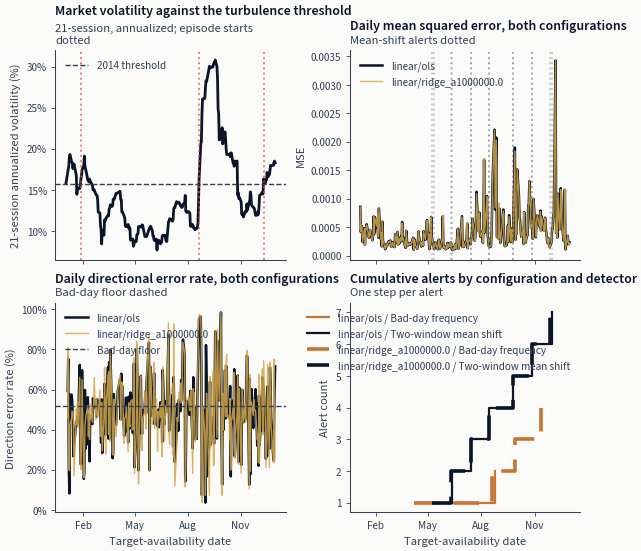

In [21]:
alert_frame = pd.DataFrame(alert_history)
if not alert_frame.empty:
    alert_frame["timestamp"] = pd.to_datetime(alert_frame["timestamp"])

fig, axes = plt.subplots(
    2, 2, figsize=FIGSIZE["dashboard_2x2"], sharex="col", constrained_layout=True
)

ax1 = axes[0, 0]
ax1.plot(
    monitored_market["timestamp"],
    monitored_market[ROLLING_VOL],
    color=COLORS["blue"],
    linewidth=2,
)
ax1.axhline(
    stress_threshold,
    color=COLORS["neutral"],
    linestyle="--",
    linewidth=1,
    label=f"{CALIBRATION_YEAR} threshold",
)
for stress_date in stress_starts:
    ax1.axvline(stress_date, color=COLORS["negative"], linestyle=":", alpha=0.7)
add_message_title(
    ax1,
    "Market volatility against the turbulence threshold",
    subtitle=f"{STRESS_VOL_WINDOW}-session, annualized; episode starts dotted",
)
ax1.set_ylabel(f"{STRESS_VOL_WINDOW}-session annualized volatility (%)")
format_pct_axis(ax1)
ax1.legend()

# The two configurations' error streams overlap closely, so the second is drawn thinner and
# semi-transparent: painted at equal weight it would simply cover the first.
MODEL_STYLE = {
    MODEL_OLS: {"color": COLORS["blue"], "linewidth": 1.8, "alpha": 1.0},
    MODEL_RIDGE: {"color": COLORS["amber"], "linewidth": 1.0, "alpha": 0.85},
}

ax2 = axes[0, 1]
for model_name, style in MODEL_STYLE.items():
    model_frame = daily_errors[daily_errors["model"] == model_name]
    ax2.plot(model_frame["timestamp"], model_frame["mse"], label=model_name, **style)
if not alert_frame.empty:
    adwin_alerts = alert_frame[alert_frame["detector"] == DETECTOR_MEAN_SHIFT]
    for _, row in adwin_alerts.iterrows():
        ax2.axvline(row["timestamp"], color=COLORS["neutral"], linestyle=":", alpha=0.25)
add_message_title(
    ax2,
    "Daily mean squared error, both configurations",
    subtitle="Mean-shift alerts dotted",
)
ax2.set_ylabel("MSE")
ax2.legend()

ax3 = axes[1, 0]
for model_name, style in MODEL_STYLE.items():
    model_frame = daily_errors[daily_errors["model"] == model_name]
    ax3.plot(
        model_frame["timestamp"],
        model_frame["direction_error_rate"],
        label=model_name,
        **style,
    )
ax3.axhline(
    BAD_DAY_FLOOR, color=COLORS["neutral"], linestyle="--", linewidth=1, label="Bad-day floor"
)
add_message_title(
    ax3,
    "Daily directional error rate, both configurations",
    subtitle="Bad-day floor dashed",
)
ax3.set_ylabel("Direction error rate (%)")
ax3.set_xlabel("Target-availability date")
format_pct_axis(ax3)
ax3.legend()

ax4 = axes[1, 1]
if not alert_frame.empty:
    cumulative = (
        alert_frame.groupby(["timestamp", "model", "detector"]).size().rename("count").reset_index()
    )
    # Colour separates the detectors and dash pattern separates the configurations. Four
    # hues would not work here: two of the palette's darks are indistinguishable at this
    # size, and two of these four curves land on nearly the same dates.
    detector_color = {
        DETECTOR_MEAN_SHIFT: COLORS["blue"],
        DETECTOR_BAD_DAY: COLORS["copper"],
    }
    # A coarse dash on a wider line, drawn second: the two mean-shift curves alert on
    # nearly the same sessions, so a fine dash over an identical solid line is invisible.
    model_style = {
        MODEL_OLS: {"linestyle": "-", "linewidth": 1.6},
        MODEL_RIDGE: {"linestyle": (0, (7, 4)), "linewidth": 2.6},
    }
    for (model_name, detector_name), series_frame in cumulative.groupby(["model", "detector"]):
        series_frame = series_frame.sort_values("timestamp")
        ax4.step(
            series_frame["timestamp"],
            series_frame["count"].cumsum(),
            where="post",
            label=f"{model_name} / {detector_name}",
            color=detector_color[detector_name],
            **model_style[model_name],
        )
add_message_title(
    ax4,
    "Cumulative alerts by configuration and detector",
    subtitle="One step per alert",
)
ax4.set_ylabel("Alert count")
ax4.set_xlabel("Target-availability date")
ax4.legend(fontsize=8)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

show_with_alt(
    fig,
    "Four-panel detector dashboard over the monitored year. Top left: annualized rolling "
    "market volatility with a dashed horizontal threshold and dotted vertical lines where a "
    "turbulent episode begins. Top right: daily mean squared error for both configurations, "
    "with faint dotted verticals at each mean-shift alert. Bottom left: daily directional "
    "error rate for both configurations against a dashed bad-day floor. Bottom right: four "
    "step curves of cumulative alert count, coloured by detector and dashed by "
    "configuration.",
)

What a desk takes from this is a dated queue: on which sessions did which configuration trip
which detector, and was the market unusual on those sessions. That is an escalation list, and
what it points to is an investigation rather than a retrain. An alert says the error stream
changed; it does not say whether the data broke, the market moved or the model decayed, and
those three call for different responses.

The bottom-right panel is worth reading twice. Colour separates the detectors and the dash
pattern separates the configurations, so a pair of curves running together means two
configurations tripped the same detector on nearly the same sessions. That narrows the
cause: something both models see moved. It does not identify what, and it does not rule out
both models degrading together, which two models fitted on the same features and the same
history can do.

The same care applies to reading the alerts against the volatility panel. An alert cluster
sitting on a turbulent stretch means the error stream changed while conditions changed, which
is a coincidence in time and not a cause; it is a reason to ask whether the strategy is sized
for those conditions before asking whether the model is broken. A cluster in a quiet stretch
removes one candidate explanation and leaves the rest, since the volatility proxy sees the
size of market moves and not a change in how features relate to returns.

Neither reading is a diagnosis. What the queue supports is an ordering of what to check
first, and the checks themselves are elsewhere: data integrity in
[`01_drift_monitoring`](01_drift_monitoring.ipynb), and a candidate model in
[`03_safe_model_rollout`](03_safe_model_rollout.ipynb).

## Key Takeaways

1. A sequential detector has to be calibrated on a period it is not then judged over.
   Calibrating and monitoring on the same sessions lets the detector tune itself to the
   shift it is supposed to find.
2. Choose the detector for the failure you care about. A two-window mean-shift test finds
   errors that grow; a bad-day frequency monitor finds a model that is wrong slightly more
   often. A stream can trip one and not the other, and neither is the more sensitive one in
   general.
3. An alert is not a degradation label. Without an independent measure of what the market
   was doing, there is no way to tell a model that broke from a market that moved, and the
   turbulence proxy here is what makes that distinction available at all.
4. Keep the sign when measuring alert timing. Averaging absolute distances to the nearest
   episode hides the difference between a detector that warns early and one that confirms
   what already happened, which is the only thing the timing was measured for.
5. Check that two configurations being compared are actually different streams. Shrinkage is
   continuous, so two registered configurations can produce predictions that agree to five
   decimal places, and a detector comparison across them would report noise as a finding.

**Known limitations**

- The turbulence proxy is a volatility measure, not a regime label. It says the market moved
  more, not that anything about the model changed, and quiet regime shifts are invisible to
  it.
- Both detectors run over a single year on a single universe. Alert counts on one year say
  nothing about the false-alarm rate, which needs many periods to estimate.
- The lead-lag measure pairs each alert with the nearest episode in either direction, so it
  reports a distance even when the two are unrelated. It describes timing; it does not
  establish that the detector responded to the episode.
- Both detectors are calibrated on the first quarter of the same year they monitor. That is
  the shortest calibration the sessions allow and it makes their thresholds noisy.

**Next**: See `03_safe_model_rollout` for incumbent-candidate testing and staged rollout using the same real prediction artifacts.